# Slanted-edge MTF — interactive widget

A self-contained version of the [ImageJ MTF plugin](https://imagej.net/ij/plugins/mtf.html) idea,
as a CIL-`islicer`-style jupyter widget: put a ROI over one straight, high-contrast,
**slightly slanted** edge and read the ESF / LSF / MTF live.

Method (ISO 12233 slanted edge):

1. **edge** — sub-pixel position on each line of the ROI, fitted with a polynomial;
2. **ESF** — pool every pixel by its distance to that edge, binned at 1/`oversample` px; the slant
   is what supplies the sub-pixel sampling, so the edge must drift ≳ 1 px across the ROI;
3. **LSF** — differentiate, window, trim about the edge;
4. **MTF** — `|FFT(LSF)|`, normalised at zero frequency.

Reported: **MTF50 / MTF20 / MTF10** in lp/mm, the fitted **edge angle**, and the **10–90 % edge
width**. Everything needed is in this notebook — no other modules.

## 1. Imports

In [36]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle
from scipy.ndimage import convolve
from scipy.special import erf

import ipywidgets as widgets
from ipywidgets import interactive_output
from IPython.display import display

## 2. The MTF calculation

In [37]:
# ---------------------------------------------------------------- MTF maths --
def _edge_fit(sub, deg=1, smooth_rows=5):
    """Sub-pixel edge position for each row of `sub`, plus a robust polynomial fit.

    `sub` is the ROI with the edge running *down* the rows (i.e. the step is
    along the columns). 
    """
    s = np.asarray(sub, dtype=float)
    n = min(smooth_rows, s.shape[0])
    if n > 1:
        s = convolve(s, np.ones((n, 1)) / n, mode='nearest')

    d = np.abs(np.diff(s, axis=1))
    x = np.arange(d.shape[1]) + 0.5
    d = d * (np.abs(x - x[d.argmax(axis=1)][:, None]) <= 3)   # dominant step only
    with np.errstate(invalid='ignore', divide='ignore'):
        pos = (d * x).sum(1) / d.sum(1)

    rows = np.arange(len(pos), dtype=float)
    ok = np.isfinite(pos)
    if ok.sum() < deg + 2:
        raise ValueError('no edge found in the ROI')
    coef = np.polyfit(rows[ok], pos[ok], deg)
    for _ in range(3):                                        # trim outliers, refit
        resid = pos - np.polyval(coef, rows)
        keep = ok & (np.abs(resid) <= 2 * np.nanstd(resid))
        if keep.sum() < deg + 3:
            break
        coef = np.polyfit(rows[keep], pos[keep], deg)
    return pos, np.polyval(coef, rows), np.polyval(np.polyder(coef), rows)


def _cross(x, y, level, rising):
    """First x where y crosses `level` (linear interpolation), else nan."""
    i = np.flatnonzero(y > level if rising else y < level)
    if len(i) == 0 or i[0] == 0:
        return np.nan
    j = i[0]
    return (np.interp(level, [y[j - 1], y[j]], [x[j - 1], x[j]]) if rising else
            np.interp(level, [y[j], y[j - 1]], [x[j], x[j - 1]]))


def measure_mtf(image, roi, orient='vertical', voxel_mm=1.0, slices=None,
                oversample=4, half_width=6.0, edge_deg=1):
    """Slanted-edge MTF from a rectangular ROI containing one step edge.

    image       2D array, or 3D (slice, y, x) together with `slices`
    roi         (x0, y0, x1, y1) in pixels
    orient      'vertical' for a near-vertical edge, 'horizontal' otherwise
    voxel_mm    pixel size in mm; frequencies come out in lp/mm
    oversample  ESF bins per pixel
    half_width  how far either side of the edge, in pixels, to keep the LSF
    edge_deg    degree of the edge fit; use 2 if the edge is visibly curved
    """
    img = np.asarray(image, dtype=float)
    planes = ([img[k] for k in (range(img.shape[0]) if slices is None else slices)]
              if img.ndim == 3 else [img])
    x0, y0, x1, y1 = roi
    dist, val, slopes = [], [], []

    for plane in planes:
        sub = plane[y0:y1, x0:x1]
        if orient == 'horizontal':
            sub = sub.T
        # 1. sub-pixel edge position along the ROI
        _, edge, slope = _edge_fit(sub, edge_deg)
        # 2. every pixel's signed distance to the edge, along the edge normal
        dist.append(((np.arange(sub.shape[1]) - edge[:, None])
                     / np.hypot(1.0, slope[:, None])).ravel())
        val.append(sub.ravel())
        slopes.append(slope.mean())

    dist, val = np.concatenate(dist), np.concatenate(val)

    # 3. ESF: bin the scatter at 1/oversample px (the slant gives the sub-pixel phases)
    step = 1.0 / oversample
    idx = ((dist - dist.min()) / step).astype(int)
    cnt, tot = np.bincount(idx), np.bincount(idx, weights=val)
    keep = cnt > 0
    centres = dist.min() + (np.arange(len(cnt)) + 0.5) * step
    esf_x = np.arange(dist.min(), dist.max(), step)
    esf = np.interp(esf_x, centres[keep], tot[keep] / cnt[keep])

    # 4. LSF: derivative of the ESF, oriented as a rising edge, trimmed about the edge.
    #    The 1 px boxcar kills the 1 cycle/px ripple from uneven sub-pixel sampling.
    k = oversample
    esf = np.convolve(np.pad(esf, k, mode='edge'), np.ones(k) / k, mode='same')[k:-k]
    lsf = np.gradient(esf, step)
    if esf[-1] < esf[0]:
        lsf = -lsf
    c = int(np.argmin(np.abs(esf_x)))                 # the edge sits at distance 0
    h = min(int(round(half_width * oversample)), c, len(lsf) - 1 - c)
    if h < 4:
        raise ValueError('edge too close to the ROI border - widen the ROI')
    sl = slice(c - h, c + h + 1)
    lsf_x, lsf = esf_x[sl], lsf[sl]

    # 5. MTF: |FFT| of the windowed LSF, normalised at zero frequency.
    #    Zero padding only interpolates the curve, it does not change its shape.
    nfft = 8 * len(lsf)
    mtf = np.abs(np.fft.rfft(lsf * np.hanning(len(lsf)), n=nfft))
    mtf /= mtf[0]
    freq = np.fft.rfftfreq(nfft, d=step) / voxel_mm                    # lp/mm

    # 6. 10-90 % rise distance over the same window
    prof = esf[sl] if esf[-1] > esf[0] else -esf[sl]
    lo, hi = prof[:oversample].mean(), prof[-oversample:].mean()
    rise = (prof - lo) / (hi - lo)
    width = (_cross(lsf_x, rise, 0.9, True) - _cross(lsf_x, rise, 0.1, True)) * voxel_mm

    return dict(esf_x=esf_x, esf=esf, lsf_x=lsf_x, lsf=lsf, freq=freq, mtf=mtf,
                mtf50=_cross(freq, mtf, 0.5, False),
                mtf20=_cross(freq, mtf, 0.2, False),
                mtf10=_cross(freq, mtf, 0.1, False),
                edge_width_mm=width,
                angle_deg=np.degrees(np.arctan(np.mean(slopes))),
                nyquist=0.5 / voxel_mm, roi=tuple(roi), orient=orient,
                voxel_mm=voxel_mm, n_slices=len(planes))

## 3. The widget

The controls sit to the left of the figure, one short tab at a time, so the sliders and the image
are visible together:

* **ROI** — type exact pixel numbers into the `x0 x1 / y0 y1` boxes, or drag the range sliders
  (grab the middle of a band to move the whole ROI); boxes and sliders track each other, and
  `w.set_roi(x0, y0, x1, y1)` does the same from code. Then the edge orientation (`auto` takes the
  axis with the larger mean gradient).
* **View** — `Zoom to ROI` / `Whole image` buttons with a padding slider, the greyscale window, and
  view-range sliders to pan/zoom by hand. The view never affects the measurement.
* **Fit** — edge-fit degree, ESF oversampling, LSF half-width, and which slice / how many
  neighbouring slices are pooled into the ESF (recons are noisy and the LSF is a derivative, so
  pool plenty).
* **Export** — `Capture` adds the current measurement to a table, `Save CSV` writes it out,
  `Clear` empties it.

The middle column is a close-up of the ROI with the fitted edge drawn on it, above the ESF and LSF
plotted together (both normalised, over the LSF window). The close-up title reports the two numbers
that decide whether the measurement is valid: the **drift** of the edge along the ROI (want > 1 px)
and the **scatter** of the per-line estimates about the fit (want < 1 px).

In [38]:
# ------------------------------------------------------------- the widget ----
STYLE, LAYOUT = {'slider_width': '72%'}, widgets.Layout(width='235px')
FIELDS = ['label', 'slice', 'n_slices', 'x0', 'y0', 'x1', 'y1', 'orient', 'edge_deg',
          'oversample', 'half_width', 'angle_deg', 'mtf50', 'mtf20', 'mtf10',
          'edge_width_um', 'nyquist', 'voxel_mm']


def _lab(text, w):
    return widgets.VBox([widgets.Label(text), w])


class MTFWidget(widgets.VBox):
    """Interactive slanted-edge MTF. See `imtf`."""

    @property
    def result(self):
        """`measure_mtf` dict for the ROI currently on screen (None if it failed)."""
        return self._result

    @property
    def roi(self):
        """(x0, y0, x1, y1) currently on screen."""
        (x0, x1), (y0, y1) = self._roi_x.value, self._roi_y.value
        return (x0, y0, x1, y1)

    def set_roi(self, x0, y0, x1, y1):
        """Move the ROI from code; the display and `result` update immediately."""
        self._roi_x.value, self._roi_y.value = (int(x0), int(x1)), (int(y0), int(y1))
        return self.roi

    def capture(self, label=None):
        """Add the current measurement to the export table; returns the row."""
        if self._result is None:
            raise RuntimeError('no valid measurement on screen')
        r = self._result
        x0, y0, x1, y1 = r['roi']
        row = dict(label=label or self._label.value or f'roi {len(self._rows) + 1}',
                   slice=self._slice.value, n_slices=r['n_slices'],
                   x0=x0, y0=y0, x1=x1, y1=y1, orient=r['orient'],
                   edge_deg=self._deg.value, oversample=self._over.value,
                   half_width=self._hw.value, angle_deg=r['angle_deg'],
                   mtf50=r['mtf50'], mtf20=r['mtf20'], mtf10=r['mtf10'],
                   edge_width_um=r['edge_width_mm'] * 1000, nyquist=r['nyquist'],
                   voxel_mm=r['voxel_mm'])
        self._rows.append(row)
        self._curves.append((row['label'], r['freq'], r['mtf']))
        self._show_table()
        return row

    def table(self):
        """Captured measurements as a DataFrame (one row per capture)."""
        return pd.DataFrame(self._rows, columns=FIELDS)

    def curves(self):
        """Captured MTF curves as a DataFrame: lp/mm index, one column per capture."""
        if not self._curves:
            return pd.DataFrame()
        f = self._curves[0][1]
        return pd.DataFrame({lab: np.interp(f, fi, m) for lab, fi, m in self._curves},
                            index=pd.Index(f, name='freq_lp_per_mm'))

    def save(self, prefix=None):
        """Write <prefix>_mtf.csv (the table) and <prefix>_mtf_curves.csv."""
        prefix = prefix or self._prefix.value or 'mtf'
        self.table().to_csv(f'{prefix}_mtf.csv', index=False)
        self.curves().to_csv(f'{prefix}_mtf_curves.csv')
        return f'{prefix}_mtf.csv', f'{prefix}_mtf_curves.csv'

    # ---------------------------------------------------------------- internals
    def _show_table(self):
        self._out_table.clear_output(wait=True)
        with self._out_table:
            if self._rows:
                display(self.table().round(3))
            else:
                print('nothing captured yet')

    def _draw(self, s, nsl, win, vx, vy, rx, ry, orient, deg, over, hw):
        (x0, x1), (y0, y1) = rx, ry
        plane = self._vol[s] if self._vol.ndim == 3 else self._vol
        lo = max(0, s - nsl // 2)
        sel = range(lo, min(self._vol.shape[0], lo + nsl)) if self._vol.ndim == 3 else None

        fig = plt.figure(figsize=self._size)
        gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=(1.0, .75, .9))
        ax_im = fig.add_subplot(gs[:, 0])
        ax_roi, ax_prof = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
        ax_mtf = fig.add_subplot(gs[:, 2])
        clim = self._clim[0] + np.asarray(win) / 100 * (self._clim[1] - self._clim[0])

        # --- image, zoomed to the view window, with the ROI drawn on it -------
        ax_im.imshow(plane, cmap=self._cmap, origin='lower', vmin=clim[0], vmax=clim[1])
        ax_im.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, ec='r', fc='none', lw=1.2))
        ax_im.set(xlim=vx, ylim=vy, xlabel='horizontal [px]', ylabel='vertical [px]',
                  title=f'{self._title}  slice {s}' if self._vol.ndim == 3 else self._title)

        if orient == 'auto':
            sub = plane[y0:y1, x0:x1]
            orient = ('vertical' if np.abs(np.diff(sub, axis=1)).mean()
                      >= np.abs(np.diff(sub, axis=0)).mean() else 'horizontal')

        # --- ROI close-up with the fitted edge --------------------------------
        sub = plane[y0:y1, x0:x1]
        ax_roi.imshow(sub, cmap=self._cmap, origin='lower', vmin=clim[0], vmax=clim[1],
                      extent=[x0, x1, y0, y1], aspect='auto')
        try:
            pos, fit, _ = _edge_fit(sub if orient == 'vertical' else sub.T, deg)
            a = np.arange(len(fit)) + 0.5
            if orient == 'vertical':
                ax_roi.plot(x0 + fit, y0 + a, 'r-', lw=1)
                ax_roi.plot(x0 + pos, y0 + a, 'r.', ms=2, alpha=.5)
            else:
                ax_roi.plot(x0 + a, y0 + fit, 'r-', lw=1)
                ax_roi.plot(x0 + a, y0 + pos, 'r.', ms=2, alpha=.5)
            drift, scatter = np.ptp(fit), np.nanstd(pos - fit)
            ax_roi.set_title(f'ROI + edge fit\ndrift {drift:.1f} px (>1)\n'
                             f'scatter {scatter:.2f} px (<1)', fontsize=8)
        except Exception:
            ax_roi.set_title('ROI (no edge fit)', fontsize=8)

        # --- the measurement ---------------------------------------------------
        self._result = None
        try:
            r = measure_mtf(self._vol, (x0, y0, x1, y1), orient=orient,
                            voxel_mm=self._voxel_mm, slices=sel, oversample=over,
                            half_width=hw, edge_deg=deg)
        except Exception as e:
            ax_prof.text(.5, .5, f'{type(e).__name__}:\n{e}', color='r', fontsize=8,
                         ha='center', va='center', wrap=True, transform=ax_prof.transAxes)
            for a in (ax_prof, ax_mtf):
                a.set_xticks([]); a.set_yticks([])
            plt.tight_layout(); plt.show()
            return
        self._result = r

        px = self._voxel_mm == 1.0          # unit-less data: work in pixels
        f_unit, x_unit = ('cycles/px', 'px') if px else ('lp/mm', 'mm')
        width = (f"{r['edge_width_mm']:.2f} px" if px
                 else f"{r['edge_width_mm'] * 1000:.0f} µm")

        # ESF and LSF share a panel, both normalised, over the LSF window
        esf = r['esf'] if r['esf'][-1] > r['esf'][0] else -r['esf']
        ax_prof.plot(r['esf_x'] * self._voxel_mm,
                     (esf - esf.min()) / np.ptp(esf), lw=1, label='ESF')
        ax_prof.plot(r['lsf_x'] * self._voxel_mm,
                     r['lsf'] / np.abs(r['lsf']).max(), lw=1, label='LSF')
        ax_prof.set(xlabel=f'distance from edge [{x_unit}]', ylabel='normalised',
                    xlim=(r['lsf_x'][0] * self._voxel_mm, r['lsf_x'][-1] * self._voxel_mm))
        ax_prof.legend(fontsize=7, loc='upper left')

        ax_mtf.plot(r['freq'], r['mtf'], lw=1.5)
        ax_mtf.axvline(r['nyquist'], ls=':', c='k')
        for y in (0.5, 0.2, 0.1):
            ax_mtf.axhline(y, ls=':', c='0.7')
        ax_mtf.set(xlabel=f_unit, ylabel='MTF', title='MTF', ylim=(0, 1.05),
                   xlim=(0, 1.2 * r['nyquist']))
        ax_mtf.text(.97, .95,
                    f"{orient} edge, {r['angle_deg']:.1f}°\n"
                    f"MTF50 {r['mtf50']:.3f} {f_unit}\nMTF20 {r['mtf20']:.3f}\n"
                    f"MTF10 {r['mtf10']:.3f}\n10-90% {width}\n"
                    f"Nyquist {r['nyquist']:.2f}", transform=ax_mtf.transAxes,
                    ha='right', va='top', fontsize=8, bbox=dict(fc='w', alpha=.8, ec='0.7'))
        plt.tight_layout()
        plt.show()


def imtf(data, roi, voxel_mm=1.0, slice_number=None, n_slices=1, orient='auto',
         edge_deg=1, oversample=4, half_width=6.0, cmap='gray', size=(10, 5.0),
         title='MTF', prefix='mtf', play_interval=500):
    """Interactive slanted-edge MTF widget (ImageJ MTF plugin, CIL islicer style).

    Parameters
    ----------
    data : ndarray or CIL DataContainer
        2D image, or a 3D stack indexed as (slice, vertical, horizontal).
    roi : (x0, y0, x1, y1)
        Starting ROI in pixels, straddling the edge; adjust it with the sliders.
    voxel_mm : float
        Pixel size in mm; frequencies are reported in lp/mm.
    slice_number, n_slices : int
        Central slice, and how many neighbouring slices are pooled into the ESF.
    orient : {'auto', 'vertical', 'horizontal'}
        Edge direction; 'auto' takes the axis with the larger mean gradient.
    edge_deg, oversample, half_width :
        Initial `measure_mtf` settings (edge fit degree, ESF bins per pixel, and
        how far either side of the edge the LSF is kept).
    prefix : str
        Default filename stem for the CSV export.

    Returns
    -------
    w : MTFWidget
        Display it, then use `w.result`, `w.roi`, `w.capture()`, `w.table()`,
        `w.curves()` and `w.save()`.
    """
    vol = data.as_array() if hasattr(data, 'as_array') else np.asarray(data)
    if vol.ndim not in (2, 3):
        raise ValueError(f'expected a 2D or 3D array, got {vol.ndim}D')
    ny, nx = vol.shape[-2:]
    nz = vol.shape[0] if vol.ndim == 3 else 1
    x0, y0, x1, y1 = (int(v) for v in roi)
    if not (0 <= x0 < x1 <= nx and 0 <= y0 < y1 <= ny):
        raise ValueError(f'roi {tuple(roi)} outside the {nx} x {ny} image')
    slice_number = nz // 2 if slice_number is None else slice_number
    flat = (vol.ndim == 2)

    def islider(hi, val, lo=0, **kw):
        kw.setdefault('continuous_update', False)
        return widgets.IntSlider(min=lo, max=hi, value=val, layout=LAYOUT, style=STYLE, **kw)

    def rslider(hi, val):
        return widgets.IntRangeSlider(min=0, max=hi, value=val, continuous_update=False,
                                      layout=LAYOUT, style=STYLE)

    w = MTFWidget()
    w._vol, w._voxel_mm, w._cmap, w._size, w._title = vol, voxel_mm, cmap, size, title
    w._clim, w._result, w._rows, w._curves = (vol.min(), vol.max()), None, [], []

    slice_w = islider(nz - 1, slice_number, disabled=flat, continuous_update=True)
    play = widgets.Play(min=0, max=nz - 1, value=slice_number, interval=play_interval)
    widgets.jslink((play, 'value'), (slice_w, 'value'))
    nsl_w = widgets.IntSlider(min=1, max=max(nz, 1), value=min(n_slices, nz),
                              continuous_update=False, layout=LAYOUT, style=STYLE,
                              disabled=flat)
    win_w = widgets.IntRangeSlider(min=0, max=100, step=5, value=[0, 100],
                                   continuous_update=True, layout=LAYOUT, style=STYLE)
    view_x, view_y = rslider(nx, (0, nx)), rslider(ny, (0, ny))
    roi_x, roi_y = rslider(nx, (x0, x1)), rslider(ny, (y0, y1))
    def ibox(val, hi, desc):
        return widgets.BoundedIntText(value=val, min=0, max=hi, description=desc,
                                      layout=widgets.Layout(width='120px'),
                                      style={'description_width': '20px'})

    x0_w, x1_w = ibox(x0, nx, 'x0'), ibox(x1, nx, 'x1')
    y0_w, y1_w = ibox(y0, ny, 'y0'), ibox(y1, ny, 'y1')

    def sync(slider, lo_w, hi_w):
        """Keep a range slider and its pair of number boxes showing the same thing."""
        busy = []
        def to_boxes(change):
            if not busy:
                busy.append(1)
                lo_w.value, hi_w.value = change['new']
                busy.clear()
        def to_slider(_):
            lo, hi = lo_w.value, hi_w.value
            if not busy and hi > lo:          # ignore x1 <= x0, keep the last good ROI
                busy.append(1)
                slider.value = (lo, hi)
                busy.clear()
        slider.observe(to_boxes, 'value')
        lo_w.observe(to_slider, 'value')
        hi_w.observe(to_slider, 'value')

    sync(roi_x, x0_w, x1_w)
    sync(roi_y, y0_w, y1_w)

    orient_w = widgets.Dropdown(options=['auto', 'vertical', 'horizontal'], value=orient,
                                layout=LAYOUT)
    deg_w, over_w = islider(3, edge_deg, lo=1), islider(16, oversample, lo=2)
    hw_w = widgets.FloatSlider(min=2, max=30, step=0.5, value=half_width,
                               continuous_update=False, layout=LAYOUT, style=STYLE)

    # zoom helpers: keep the view on the ROI, or go back to the whole image
    pad_w = widgets.IntSlider(min=0, max=100, value=20, continuous_update=False,
                              description='pad px', layout=LAYOUT, style=STYLE)
    zoom_b = widgets.Button(description='Zoom to ROI', icon='search-plus',
                            layout=widgets.Layout(width='122px'))
    reset_b = widgets.Button(description='Whole image', icon='expand',
                             layout=widgets.Layout(width='122px'))

    def zoom(_):
        p = pad_w.value
        view_x.value = (max(0, roi_x.value[0] - p), min(nx, roi_x.value[1] + p))
        view_y.value = (max(0, roi_y.value[0] - p), min(ny, roi_y.value[1] + p))

    def reset(_):
        view_x.value, view_y.value = (0, nx), (0, ny)

    zoom_b.on_click(zoom)
    reset_b.on_click(reset)

    # export
    w._label = widgets.Text(placeholder='label for this ROI', layout=LAYOUT)
    w._prefix = widgets.Text(value=prefix, description='file stem', layout=LAYOUT,
                             style={'description_width': '70px'})
    cap_b = widgets.Button(description='Capture', icon='thumbtack', button_style='info',
                           layout=widgets.Layout(width='122px'))
    csv_b = widgets.Button(description='Save CSV', icon='download',
                           layout=widgets.Layout(width='122px'))
    clr_b = widgets.Button(description='Clear', icon='trash',
                           layout=widgets.Layout(width='122px'))
    w._out_table = widgets.Output()
    msg = widgets.HTML()

    def on_capture(_):
        try:
            row = w.capture()
            msg.value = f"captured <b>{row['label']}</b> (MTF50 {row['mtf50']:.3f} lp/mm)"
        except Exception as e:
            msg.value = f'<span style="color:red">{e}</span>'

    def on_save(_):
        try:
            msg.value = 'written: ' + ', '.join(f'<code>{f}</code>' for f in w.save())
        except Exception as e:
            msg.value = f'<span style="color:red">{e}</span>'

    def on_clear(_):
        w._rows.clear(); w._curves.clear(); w._show_table(); msg.value = 'table cleared'

    cap_b.on_click(on_capture); csv_b.on_click(on_save); clr_b.on_click(on_clear)

    # one short tab at a time, so the ROI controls stay level with the image
    tab_layout = widgets.Layout(width='258px')
    controls = widgets.Tab([
        widgets.VBox([widgets.HBox([x0_w, x1_w]), widgets.HBox([y0_w, y1_w]),
                      _lab('ROI: horizontal', roi_x), _lab('ROI: vertical', roi_y),
                      _lab('edge orientation', orient_w)]),
        widgets.VBox([widgets.HBox([zoom_b, reset_b]), pad_w,
                      _lab('display window percent', win_w),
                      _lab('view: horizontal', view_x), _lab('view: vertical', view_y)]),
        widgets.VBox([_lab('edge fit degree', deg_w), _lab('ESF oversampling', over_w),
                      _lab('LSF half width [px]', hw_w),
                      widgets.HBox([play, slice_w]), _lab('slices pooled', nsl_w)]),
        widgets.VBox([w._label, widgets.HBox([cap_b, clr_b]), widgets.HBox([csv_b]),
                      w._prefix]),
    ], layout=tab_layout)
    controls.titles = ('ROI', 'View', 'Fit', 'Export')

    w._slice, w._deg, w._over, w._hw = slice_w, deg_w, over_w, hw_w
    w._roi_x, w._roi_y = roi_x, roi_y
    out = interactive_output(w._draw, dict(
        s=slice_w, nsl=nsl_w, win=win_w, vx=view_x, vy=view_y, rx=roi_x, ry=roi_y,
        orient=orient_w, deg=deg_w, over=over_w, hw=hw_w))

    w.children = [widgets.HBox([controls, out],
                               layout=widgets.Layout(flex_flow='row wrap')),
                  msg, w._out_table]
    w._show_table()
    return w

## 4. First, a test image

Before trusting the widget on real data, point it at an edge whose answer is known: black on the
left, white on the right, tilted 5° off vertical, blurred with a Gaussian of σ = 1.2 px (plus a
little noise, and 8 independent "slices" to pool). A Gaussian blur has the analytic MTF

$$\mathrm{MTF}(f) = e^{-2(\pi\sigma f)^2}, \qquad f \text{ in cycles/px,}$$

so the measured curve can be checked against it directly.

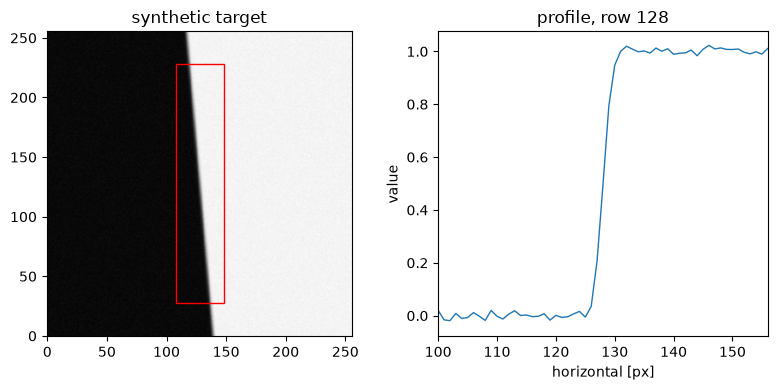

In [39]:
def slanted_edge(size=256, angle_deg=5.0, sigma_px=1.2, noise=0.01, n_slices=8, seed=0):
    """Synthetic slanted-edge target: 0 on the left, 1 on the right.

    The edge is tilted `angle_deg` off vertical and blurred by a Gaussian of
    `sigma_px` (exactly, via the error function), then `n_slices` copies are made
    with independent gaussian noise. Analytic MTF: exp(-2 (pi sigma f)^2).
    """
    y, x = np.mgrid[0:size, 0:size]
    a = np.radians(angle_deg)
    d = (x - size / 2 + np.tan(a) * (y - size / 2)) * np.cos(a)   # distance to the edge
    img = 0.5 * (1 + erf(d / (sigma_px * np.sqrt(2))))
    rng = np.random.default_rng(seed)
    return np.stack([img + rng.normal(0, noise, img.shape) for _ in range(n_slices)])


SIGMA_PX, TEST_VOXEL_MM = 1.2, 0.1        # 100 um pixels -> Nyquist 5 lp/mm
test = slanted_edge(sigma_px=SIGMA_PX)
TEST_ROI = (108, 28, 148, 228)            # tall and narrow, edge centred, nothing else inside

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(test[0], cmap='gray', origin='lower')
ax[0].add_patch(Rectangle(TEST_ROI[:2], TEST_ROI[2] - TEST_ROI[0], TEST_ROI[3] - TEST_ROI[1],
                          ec='r', fc='none'))
ax[0].set_title('synthetic target')
ax[1].plot(test[0, 128], lw=1)
ax[1].set(xlim=(100, 156), xlabel='horizontal [px]', ylabel='value', title='profile, row 128')
fig.tight_layout()

In [40]:
wt = imtf(test, TEST_ROI, voxel_mm=TEST_VOXEL_MM, n_slices=8, half_width=8.0,
          title='synthetic slanted edge', prefix='mtf_test')
wt

MTFWidget(children=(HBox(children=(Tab(children=(VBox(children=(HBox(children=(BoundedIntText(value=108, descr…

## 5. Getting the ROIs and MTF values out

`Capture` in the widget stores whatever is on screen; `Save CSV` writes it out. The same things
are available in code:

| | |
|---|---|
| `wt.result` | full `measure_mtf` dict for the ROI on screen — ESF, LSF, MTF arrays and metrics |
| `wt.roi` | `(x0, y0, x1, y1)` on screen |
| `wt.set_roi(x0, y0, x1, y1)` | move the ROI from code |
| `wt.capture('label')` | add the current measurement to the table |
| `wt.table()` | captured measurements as a `DataFrame` (one row per capture) |
| `wt.curves()` | captured MTF curves, lp/mm index, one column per capture |
| `wt.save('stem')` | write `stem_mtf.csv` and `stem_mtf_curves.csv` |

In [41]:
r = wt.result
print('ROI', wt.roi, '|', r['orient'], f"edge, {r['angle_deg']:+.2f} deg")
print(f"MTF50 {r['mtf50']:.3f}  MTF20 {r['mtf20']:.3f}  MTF10 {r['mtf10']:.3f} lp/mm"
      f"   10-90% {r['edge_width_mm'] * 1e3:.0f} um   Nyquist {r['nyquist']:.2f} lp/mm")

wt.capture('as displayed')          # same as pressing Capture
wt.table()

ROI (108, 28, 148, 228) | vertical edge, -5.00 deg
MTF50 1.593  MTF20 2.427  MTF10 2.903 lp/mm   10-90% 319 um   Nyquist 5.00 lp/mm


,label,slice,n_slices,x0,y0,x1,y1,orient,edge_deg,oversample,half_width,angle_deg,mtf50,mtf20,mtf10,edge_width_um,nyquist,voxel_mm
0,as displayed,4,8,108,28,148,228,vertical,1,4,8.0,-4.999178,1.59312,2.42747,2.902967,319.252491,5.0,0.1


In [42]:
# or drive it from code: set a ROI, capture, repeat
for x0, x1 in [(98, 158), (118, 138)]:
    wt.set_roi(x0, 28, x1, 228)
    wt.capture(f'ROI {x1 - x0} px wide')

wt.table()[['label', 'x0', 'y0', 'x1', 'y1', 'angle_deg', 'mtf50', 'edge_width_um']]

,label,x0,y0,x1,y1,angle_deg,mtf50,edge_width_um
0,as displayed,108,28,148,228,-4.999178,1.593120,319.252491
1,ROI 60 px wide,98,28,158,228,-4.999178,1.593170,319.343416
2,ROI 20 px wide,118,28,138,228,-4.954143,1.592483,319.427158


## 6. A real image: cameraman

The synthetic target is the ideal case. On a real photograph the plateaus are textured and the
"edge" is whatever the camera and the scanner left behind, but the method is the same. CIL ships
cameraman as `dataexample.CAMERA`; the coat silhouette against the grass at lower left is a
straight edge slanted ~20° — far better slanted than anything in a CT slice.

With `voxel_mm=1.0` the frequency axis is **cycles per pixel**, so Nyquist sits at 0.5.

(Since `voxel_mm=1.0`, the `edge_width_um` column of the export table is in thousandths of a
pixel — divide by 1000 to read pixels.)

In [43]:
from cil.utilities import dataexample

cam = np.flipud(dataexample.CAMERA.get().as_array())   # flip: the widget draws origin='lower'
CAM_ROI = (46, 140, 78, 215)        # coat vs grass, straight and ~20 deg off vertical

wc = imtf(cam, CAM_ROI, voxel_mm=1.0, half_width=8.0, title='cameraman', prefix='mtf_camera')
wc

MTFWidget(children=(HBox(children=(Tab(children=(VBox(children=(HBox(children=(BoundedIntText(value=46, descri…

### Does it react the way it should?

Blur the same image with a known Gaussian and measure the same ROI: the MTF must drop and the
edge width must grow. Two widgets, one ROI, captured into one table — the same pattern as
comparing two reconstructions.

In [44]:
from scipy.ndimage import gaussian_filter

SIGMA_BLUR = 2.0
wb = imtf(gaussian_filter(cam, SIGMA_BLUR), CAM_ROI, voxel_mm=1.0, half_width=8.0,
          title=f'cameraman, blurred {SIGMA_BLUR} px', prefix='mtf_camera_blur')
wb

MTFWidget(children=(HBox(children=(Tab(children=(VBox(children=(HBox(children=(BoundedIntText(value=46, descri…

expected blurred width ~5.6 px, measured 5.1 px


,label,x0,y0,x1,y1,angle_deg,mtf50,mtf10,edge_width_um
0,cameraman,46,140,78,215,19.807827,0.208488,0.317124,2162.725705
1,blurred sigma 2.0 px,46,140,78,215,20.017002,0.107127,0.187704,5069.869202


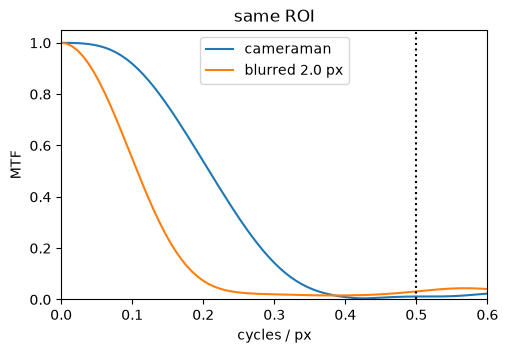

In [45]:
wc.capture('cameraman')
wb.capture(f'blurred sigma {SIGMA_BLUR} px')
both = pd.concat([wc.table(), wb.table()], ignore_index=True)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
for w_, lab in [(wc, 'cameraman'), (wb, f'blurred {SIGMA_BLUR} px')]:
    ax.plot(w_.result['freq'], w_.result['mtf'], lw=1.5, label=lab)
ax.axvline(0.5, ls=':', c='k')
ax.set(xlabel='cycles / px', ylabel='MTF', xlim=(0, 0.6), ylim=(0, 1.05), title='same ROI')
ax.legend()

# a sigma = 2 px blur should add to the edge width roughly in quadrature
w0 = both.edge_width_um[0] / 1e3    # um -> px, since voxel_mm = 1
print(f"expected blurred width ~{np.hypot(w0, 2 * 1.2816 * SIGMA_BLUR):.1f} px, "
      f"measured {both.edge_width_um[1] / 1e3:.1f} px")
both[['label', 'x0', 'y0', 'x1', 'y1', 'angle_deg', 'mtf50', 'mtf10', 'edge_width_um']]